# Ablation Study: Feature Selection for SAC-Based Gamma Controller
## Evaluasi dengan 4 Metrik: Sharpe Ratio, Sortino Ratio, Calmar Ratio, CVaR (95%)

**Tujuan:** Mengevaluasi kontribusi masing-masing kelompok fitur terhadap performa portofolio berdasarkan **4 metrik risk-adjusted** yang komprehensif untuk keperluan tesis.

> **Catatan:** Eksperimen ini menggunakan **Rolling Sharpe Ratio reward** (`ann_ret / ann_vol`).
> Agent didorong memaksimalkan return per unit risiko (volatilitas), bukan hanya return mentah.
> Cocok untuk kripto yang sangat volatile karena menghukum fluktuasi berlebihan.

### Metrik Evaluasi (4 Metrik Utama Tesis)
| Metrik | Formula | Interpretasi |
|--------|---------|-------------|
| **Sharpe Ratio** | Ann.Return / Ann.Volatility | Return per unit volatilitas total (konsisten dengan reward) |
| **Sortino Ratio** | Ann.Return / Downside Volatility | Lebih adil untuk kripto — hanya hukum volatilitas negatif |
| **Calmar Ratio** | Ann.Return / \|Max Drawdown\| | Return per unit risiko kejatuhan terburuk |
| **CVaR (95%)** | E[Loss \| Loss > VaR95%] | Rata-rata kerugian di skenario terburuk 5% (standar akademik) |

### Eksperimen Ablation
| ID | Nama Eksperimen | Fitur yang Digunakan | Keterangan |
|----|----------------|----------------------|------------|
| E0 | **Baseline** | Semua 9 fitur original | Referensi utama |
| E1 | **-Network** | Hapus 5 network features | Hanya market features |
| E2 | **-Market** | Hapus 4 market features | Hanya network features |
| E3 | **+Downside Vol** | 9 fitur + downside_vol | Tambah risk feature |
| E4 | **+Avg Corr** | 9 fitur + avg_pairwise_corr | Tambah avg correlation |
| E5 | **+Both** | 9 fitur + downside_vol + avg_corr | Semua fitur tambahan |
| E6 | **-Network +Downside Vol** | 4 market + downside_vol | Tanpa network, dengan risk feature |
| Comp_Static_Gamma0/1/2 | **Static Benchmark** | Network features saja | Gamma tetap 0 / 1 / 2 |

## Setup & Install

In [25]:
#%pip install stable_baselines3[extra]

In [26]:
# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42]  # [42, 123, 77] untuk multi-seed
TRAIN_STEPS   = 1000
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20   # sliding window untuk Rolling Sharpe Ratio reward
CVAR_LEVEL    = 0.95 # confidence level CVaR

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    'E0_Baseline'        : {'use_network': True,  'use_market': True,  'extra_features': []},
    'E1_NoNetwork'       : {'use_network': False, 'use_market': True,  'extra_features': []},
    'E2_NoMarket'        : {'use_network': True,  'use_market': False, 'extra_features': []},
    'E3_AddDownside'     : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol']},
    'E4_AddAvgCorr'      : {'use_network': True,  'use_market': True,  'extra_features': ['avg_corr']},
    'E5_AddBoth'         : {'use_network': True,  'use_market': True,  'extra_features': ['downside_vol', 'avg_corr']},
    'E6_NoNetwork_AddDownside': {'use_network': False, 'use_market': True,  'extra_features': ['downside_vol']},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('ablation_results_4metrics', exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'CVaR confidence level: {CVAR_LEVEL*100:.0f}%')

Libraries loaded.
Ablation configs: ['E0_Baseline', 'E1_NoNetwork', 'E2_NoMarket', 'E3_AddDownside', 'E4_AddAvgCorr', 'E5_AddBoth', 'E6_NoNetwork_AddDownside', 'Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2']
CVaR confidence level: 95%


## Phase 1: Data Preparation

In [27]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

Fungsi inti portofolio + **4 metrik evaluasi tesis**.

In [28]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP dengan constraint return >= mean(mu). Fallback ke equal-weight jika infeasible."""
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )
    bounds = tuple((0, 0.4) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def get_centrality_weights(returns_window, gamma=1.0):
    """Hitung bobot portofolio berbasis centrality MST + Markowitz (full recompute)."""
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    """Hitung bobot menggunakan cache (cov_f & cent_vec sudah dihitung sebelumnya)."""
    N = len(mu)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def calculate_annualized_return(ret_series, periods_per_year=252):
    """Annualized return (CAGR) dari daily returns Series."""
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_total_return(ret_series):
    """Cumulative total return dari daily returns Series."""
    return (1 + np.array(ret_series)).prod() - 1


# ================================================================
# 4 METRIK EVALUASI UTAMA TESIS
# ================================================================

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    """
    METRIK 1: Sharpe Ratio
    Formula: Annualized Return / Annualized Volatility
    Interpretasi: Return per unit risiko total (konsisten dengan reward agent).
    Semakin tinggi = semakin baik.
    """
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    if ann_vol <= 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / ann_vol


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    """
    METRIK 2: Sortino Ratio
    Formula: Annualized Return / Downside Deviation
    Downside Deviation = std(returns[returns < MAR]) * sqrt(252)
    MAR (Minimum Acceptable Return) = 0 (default)
    Interpretasi: Lebih adil dari Sharpe untuk kripto — hanya menghukum
    volatilitas negatif. Upside volatility tidak dihukum.
    Semakin tinggi = semakin baik.
    """
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    if downside_dev <= 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / downside_dev


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    """
    METRIK 3: Calmar Ratio
    Formula: Annualized Return / |Max Drawdown|
    Max Drawdown = penurunan terbesar dari peak ke trough
    Interpretasi: Return per unit risiko kejatuhan terburuk.
    Sangat intuitif untuk investor dan penguji tesis.
    Semakin tinggi = semakin baik.
    """
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr)
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    if max_dd == 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / abs(max_dd)


def calculate_cvar(ret_series, confidence=0.95):
    """
    METRIK 4: CVaR / Expected Shortfall (95%)
    Formula: E[Loss | Loss > VaR(confidence)]
    = rata-rata kerugian pada (1-confidence)% hari terburuk
    Interpretasi: Standar akademik modern untuk tail risk.
    Menjawab: 'Berapa rata-rata kerugian di 5% hari terburuk?'
    Disajikan sebagai nilai positif (loss), semakin kecil = semakin baik.
    """
    arr = np.array(ret_series)
    # VaR: persentil ke-(1-confidence) dari distribusi return
    var = np.percentile(arr, (1 - confidence) * 100)
    # CVaR: rata-rata return di bawah VaR
    tail_losses = arr[arr <= var]
    if len(tail_losses) == 0:
        return 0.0
    cvar = -np.mean(tail_losses)  # positif = kerugian
    return float(cvar)


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    """
    Hitung semua metrik evaluasi — 4 utama + metrik pendukung.
    Returns dict lengkap untuk summary table tesis.
    """
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1

    # Drawdown
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()

    # Downside stats
    downside = arr[arr < 0]
    down_std = np.std(downside) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0

    return {
        # ── 4 Metrik Utama Tesis ──────────────────────────────
        'Sharpe Ratio'  : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio' : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'  : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'    : calculate_cvar(arr, cvar_level),
        # ── Metrik Pendukung ──────────────────────────────────
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Max Drawdown'    : max_dd,
    }


print('Core functions + 4 metrik evaluasi tesis defined.')
print('Metrik utama: Sharpe Ratio | Sortino Ratio | Calmar Ratio | CVaR (95%)')

Core functions + 4 metrik evaluasi tesis defined.
Metrik utama: Sharpe Ratio | Sortino Ratio | Calmar Ratio | CVaR (95%)


## Phase 3: Feature Engineering

In [29]:
def compute_network_features(returns_window):
    """5 network features dari MST (original)."""
    T, N = returns_window.shape
    corr_f   = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,   # F1: Centrality Std
        np.mean(cent_vec) * 10,   # F2: Centrality Mean
        mst_dist          * 0.1,  # F3: MST Distance
        np.max(cent_vec),          # F4: Max Centrality
        density                    # F5: Network Density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    """4 market features (original)."""
    short_ret  = returns_window.iloc[-5:].mean().mean()
    long_ret   = returns_window.mean().mean()
    momentum   = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,
        momentum   * 100,
        recent_vol * 100,
        port_val
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    """Fitur tambahan untuk ablation study."""
    extra = []
    if 'downside_vol' in extra_list:
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)
    if 'avg_corr' in extra_list:
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))
    return np.array(extra, dtype=np.float32)


def build_observation(returns_window, config, port_val=0.0):
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])
    parts = []
    if config['use_network']: parts.append(nw_feat)
    if config['use_market']:  parts.append(mkt_feat)
    if len(extra_feat) > 0:   parts.append(extra_feat)
    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, cent_vec


def get_obs_dim(config):
    dim = 0
    if config['use_network']: dim += 5
    if config['use_market']:  dim += 4
    dim += len(config['extra_features'])
    return max(dim, 1)


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')

Feature engineering functions defined.
Observation dimensions per config:
  E0_Baseline: 9 features
  E1_NoNetwork: 4 features
  E2_NoMarket: 5 features
  E3_AddDownside: 10 features
  E4_AddAvgCorr: 10 features
  E5_AddBoth: 11 features
  E6_NoNetwork_AddDownside: 5 features
  Comp_Static_Gamma0: 5 features
  Comp_Static_Gamma1: 5 features
  Comp_Static_Gamma2: 5 features


## Phase 4: Feature Correlation Analysis

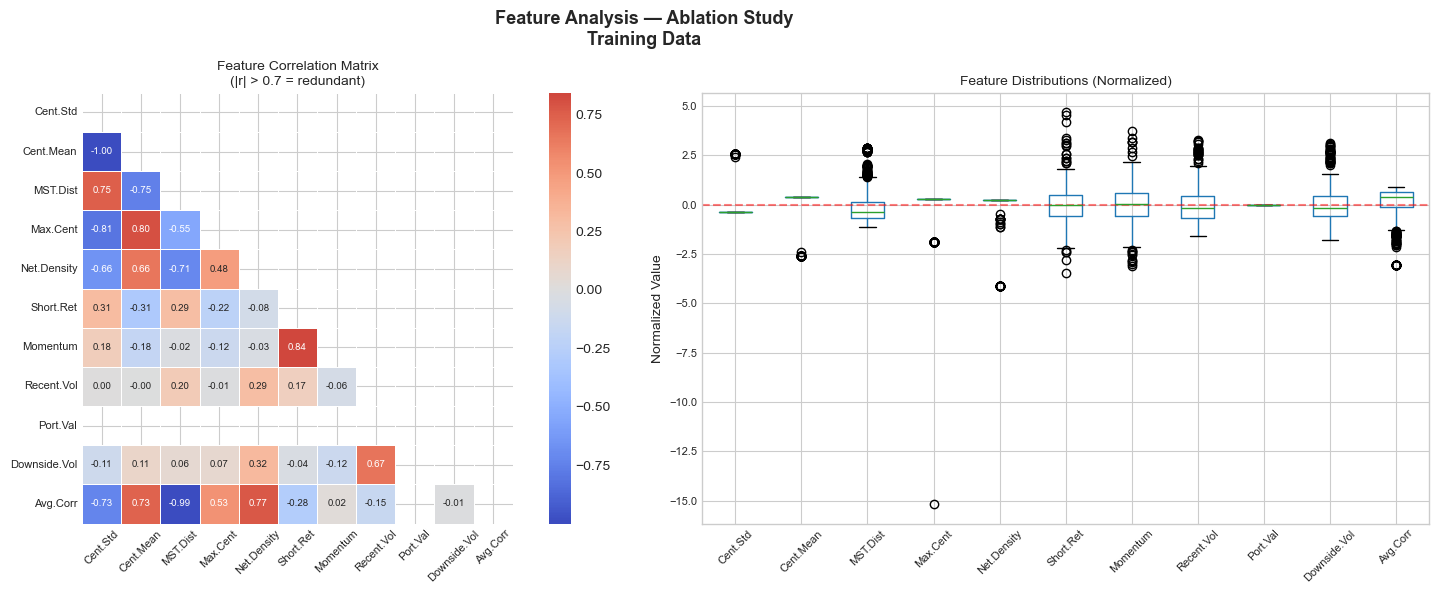


High-correlation pairs (|r| > 0.6):
  Cent.Std <-> Cent.Mean: r = -1.000
  Cent.Std <-> MST.Dist: r = 0.752
  Cent.Std <-> Max.Cent: r = -0.805
  Cent.Std <-> Net.Density: r = -0.657
  Cent.Std <-> Avg.Corr: r = -0.731
  Cent.Mean <-> MST.Dist: r = -0.752
  Cent.Mean <-> Max.Cent: r = 0.805
  Cent.Mean <-> Net.Density: r = 0.657
  Cent.Mean <-> Avg.Corr: r = 0.731
  MST.Dist <-> Net.Density: r = -0.714
  MST.Dist <-> Avg.Corr: r = -0.991
  Net.Density <-> Avg.Corr: r = 0.774
  Short.Ret <-> Momentum: r = 0.843
  Recent.Vol <-> Downside.Vol: r = 0.665


In [30]:
all_features = []
print('Collecting features for correlation analysis...')
for i in range(SET_WINDOW, len(ret_train)):
    win = ret_train.iloc[i - SET_WINDOW : i]
    nw, corr_f, _ = compute_network_features(win)
    mkt   = compute_market_features(win)
    extra = compute_extra_features(win, corr_f, ['downside_vol', 'avg_corr'])
    all_features.append(np.concatenate([nw, mkt, extra]))

feat_names = [
    'Cent.Std', 'Cent.Mean', 'MST.Dist', 'Max.Cent', 'Net.Density',
    'Short.Ret', 'Momentum', 'Recent.Vol', 'Port.Val',
    'Downside.Vol', 'Avg.Corr'
]

df_feat = pd.DataFrame(all_features, columns=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis — Ablation Study\nTraining Data', fontsize=13, fontweight='bold')

ax1 = axes[0]
corr_matrix = df_feat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5, annot_kws={'size': 7})
ax1.set_title('Feature Correlation Matrix\n(|r| > 0.7 = redundant)', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

ax2 = axes[1]
df_normalized = (df_feat - df_feat.mean()) / (df_feat.std() + 1e-8)
df_normalized.boxplot(ax=ax2, rot=45, fontsize=8)
ax2.set_title('Feature Distributions (Normalized)', fontsize=10)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('ablation_results_4metrics/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHigh-correlation pairs (|r| > 0.6):')
found = False
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {feat_names[i]} <-> {feat_names[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  (Tidak ada pasangan dengan |r| > 0.6)')

## Phase 5: Ablation Environment

Reward tetap menggunakan **Rolling Sharpe Ratio** — konsisten dengan metrik evaluasi utama.

In [31]:
def precompute_ablation_data(returns_data, config, window_size=30):
    """Precompute obs cache untuk satu ablation config."""
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    n_steps = len(returns_data) - window_size
    print(f'  Precomputing {n_steps} steps...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        obs, corr_f, cent_vec = build_observation(win, config, port_val=0.0)
        obs_cache[i] = obs
        sigma = win.std().values
        mu    = win.mean().values
        cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'  Done! obs_dim={len(obs_cache[window_size])}')
    return obs_cache, opt_cache, baseline_ret_cache


class AblationPortfolioEnv(gym.Env):
    """
    Environment untuk ablation study.
    Reward: Rolling Sharpe Ratio (konsisten dengan metrik evaluasi #1).
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache, config, window_size=30, gamma_center=1.0):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache
        self.config             = config
        self.window_size        = window_size
        self.gamma_center       = gamma_center
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        self._returns_buffer    = []
        self._sharpe_window     = REWARD_WINDOW
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        if self.config['use_market']:
            offset = 5 if self.config['use_network'] else 0
            if offset + 3 < len(obs):
                obs[offset + 3] = self.port_val - 1.0
        return obs

    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > self._sharpe_window:
            self._returns_buffer.pop(0)

        arr = np.array(self._returns_buffer)
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            sharpe     = arr.mean() * np.sqrt(252) / (arr.std() + 1e-8)
            raw_reward = float(np.clip(sharpe, -10.0, 10.0))

        reward = self._normalize_reward(raw_reward)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('AblationPortfolioEnv defined.')

AblationPortfolioEnv defined.


## Phase 6: Backtest Engine & Strategy Classes

In [32]:
class AblationStrategy:
    def __init__(self, name, model_path, config, gamma_center=1.0):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.is_static    = config.get('static_gamma') is not None
        if self.is_static:
            self.model      = None
            self.last_gamma = config['static_gamma']
        else:
            self.model      = SAC.load(model_path)
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0):
        if self.is_static:
            self.last_gamma = self.config['static_gamma']
            return get_centrality_weights(returns_window, gamma=self.last_gamma)
        obs, _, _ = build_observation(returns_window, self.config, port_val=port_val - 1.0)
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7):
    rets, dates, gamma_history = [], [], []
    current_weights = None
    current_gamma   = 1.0
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i - window : i]
            if hasattr(strategy, 'is_static') and strategy.is_static:
                current_weights = strategy.compute_weights(window_df)
            else:
                current_weights = strategy.compute_weights(window_df, port_val=port_val)
            current_gamma = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(current_gamma)
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


print('Backtest engine defined.')

Backtest engine defined.


## Phase 7: Training — Semua Ablation Configs

In [33]:
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}

sep = '=' * 60
for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')
    print(f'  Network: {config["use_network"]} | Market: {config["use_market"]} | Extra: {config["extra_features"]}')
    print('Precomputing data...')

    obs_cache, opt_cache, baseline_ret_cache = precompute_ablation_data(
        ret_train, config, window_size=SET_WINDOW
    )

    for seed in SEEDS:
        model_name = f'ablation_{exp_id}_seed{seed}'

        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} — tidak perlu training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f'  Training seed={seed}...')
        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, baseline_ret_cache, config,
            window_size=SET_WINDOW, gamma_center=GAMMA_CENTER,
        )
        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip')

print('\n=== Semua model ablation selesai dilatih ===')


Experiment: E0_Baseline | obs_dim=9
  Network: True | Market: True | Extra: []
Precomputing data...
  Precomputing 504 steps...


Output()

  Done! obs_dim=9
  Training seed=42...


    Saved: ablation_E0_Baseline_seed42.zip

Experiment: E1_NoNetwork | obs_dim=4
  Network: False | Market: True | Extra: []
Precomputing data...
  Precomputing 504 steps...


Output()

...

  Done! obs_dim=11
  Training seed=42...


    Saved: ablation_E5_AddBoth_seed42.zip

Experiment: E6_NoNetwork_AddDownside | obs_dim=5
  Network: False | Market: True | Extra: ['downside_vol']
Precomputing data...
  Precomputing 504 steps...


Output()

  Done! obs_dim=5
  Training seed=42...


    Saved: ablation_E6_NoNetwork_AddDownside_seed42.zip

Experiment: Comp_Static_Gamma0 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma0 — tidak perlu training.

Experiment: Comp_Static_Gamma1 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma1 — tidak perlu training.

Experiment: Comp_Static_Gamma2 | obs_dim=5
  Network: True | Market: False | Extra: []
Precomputing data...
  Precomputing 504 steps...
  Done! obs_dim=5
  Static benchmark Comp_Static_Gamma2 — tidak perlu training.

=== Semua model ablation selesai dilatih ===


## Phase 8: Backtest — Training & Testing Data

In [34]:
ablation_results = {}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]

        strat_tr = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_tr, _ = run_backtest(strat_tr, ret_train, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['train'][seed] = ret_tr

        strat_te = AblationStrategy(f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER)
        ret_te, _ = run_backtest(strat_te, ret_test, SET_WINDOW, SET_REBALANCE)
        ablation_results[exp_id]['test'][seed] = ret_te

        # Preview 4 metrik utama
        m_te = calculate_all_metrics(ret_te, CVAR_LEVEL)
        print(f'  seed={seed} | Sharpe={m_te["Sharpe Ratio"]:.3f} | '
              f'Sortino={m_te["Sortino Ratio"]:.3f} | '
              f'Calmar={m_te["Calmar Ratio"]:.3f} | '
              f'CVaR={m_te["CVaR (95%)"]:.4f}')

print('\nSemua backtest selesai.')


Backtest: E0_Baseline
  seed=42 | Sharpe=0.163 | Sortino=0.209 | Calmar=0.198 | CVaR=0.1033

Backtest: E1_NoNetwork
  seed=42 | Sharpe=0.240 | Sortino=0.311 | Calmar=0.294 | CVaR=0.1001

Backtest: E2_NoMarket
  seed=42 | Sharpe=-0.103 | Sortino=-0.129 | Calmar=-0.116 | CVaR=0.1046

Backtest: E3_AddDownside
  seed=42 | Sharpe=-0.085 | Sortino=-0.105 | Calmar=-0.097 | CVaR=0.1051

Backtest: E4_AddAvgCorr
  seed=42 | Sharpe=0.061 | Sortino=0.076 | Calmar=0.072 | CVaR=0.1047

Backtest: E5_AddBoth
  seed=42 | Sharpe=0.031 | Sortino=0.038 | Calmar=0.037 | CVaR=0.1053

Backtest: E6_NoNetwork_AddDownside
  seed=42 | Sharpe=0.117 | Sortino=0.151 | Calmar=0.133 | CVaR=0.0997

Backtest: Comp_Static_Gamma0
  seed=42 | Sharpe=-0.142 | Sortino=-0.177 | Calmar=-0.158 | CVaR=0.1006

Backtest: Comp_Static_Gamma1
  seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Backtest: Comp_Static_Gamma2
  seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Semua backtest 

## Phase 9: Agregasi Hasil — 4 Metrik Utama Tesis

In [35]:
# ================================================================
# AGREGASI HASIL: Mean +/- Std untuk 4 Metrik Utama
# ================================================================

summary_rows = []

for exp_id, config in ABLATION_CONFIGS.items():
    # Kumpulkan metrik per seed (train & test)
    train_metrics = [calculate_all_metrics(ablation_results[exp_id]['train'][s], CVAR_LEVEL) for s in SEEDS]
    test_metrics  = [calculate_all_metrics(ablation_results[exp_id]['test'][s],  CVAR_LEVEL) for s in SEEDS]

    # Helper: mean & std per metrik
    def agg(metrics_list, key):
        vals = [m[key] for m in metrics_list]
        return np.nanmean(vals), np.nanstd(vals)

    # Feature description
    feature_desc = []
    if config.get('static_gamma') is not None:
        feature_desc.append(f'Static Gamma {config["static_gamma"]}')
    else:
        if config['use_network']: feature_desc.append('Network(5)')
        if config['use_market']:  feature_desc.append('Market(4)')
        for e in config['extra_features']: feature_desc.append(e)

    row = {
        'Experiment' : exp_id,
        'Features'   : ' + '.join(feature_desc),
        'Obs Dim'    : get_obs_dim(config),
    }

    # 4 Metrik Utama — Train
    for metric in ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'CVaR (95%)']:
        mean, std = agg(train_metrics, metric)
        key = metric.replace(' ', '').replace('(', '').replace(')', '').replace('%', 'pct')
        row[f'{key}_Train_Mean'] = mean
        row[f'{key}_Train_Std']  = std

    # 4 Metrik Utama — Test
    for metric in ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'CVaR (95%)']:
        mean, std = agg(test_metrics, metric)
        key = metric.replace(' ', '').replace('(', '').replace(')', '').replace('%', 'pct')
        row[f'{key}_Test_Mean'] = mean
        row[f'{key}_Test_Std']  = std

    # Metrik pendukung
    tr_ann_m, tr_ann_s = agg(train_metrics, 'Ann. Return')
    te_ann_m, te_ann_s = agg(test_metrics,  'Ann. Return')
    tr_tot_m, _        = agg(train_metrics, 'Total Return')
    te_tot_m, _        = agg(test_metrics,  'Total Return')
    row['AnnRet_Train_Mean'] = tr_ann_m
    row['AnnRet_Test_Mean']  = te_ann_m
    row['TotalRet_Gap']      = tr_tot_m - te_tot_m

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('ablation_results_4metrics/ablation_summary_4metrics.csv')

# ── Print summary table ──────────────────────────────────────────
sep = '=' * 90
print(sep)
print('ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)')
print(sep)
print(f'{"Experiment":<25} {"Sharpe":>10} {"Sortino":>10} {"Calmar":>10} {"CVaR(95%)":>12}')
print('-' * 70)
for exp_id, row in summary_df.iterrows():
    print(f'{exp_id:<25} '
          f'{row["SharpeRatio_Test_Mean"]:>10.4f} '
          f'{row["SortinoRatio_Test_Mean"]:>10.4f} '
          f'{row["CalmarRatio_Test_Mean"]:>10.4f} '
          f'{row["CVaR95pct_Test_Mean"]:>12.5f}')
print(sep)

# Ranking per metrik
print('\nRANKING PER METRIK (Testing):')
for metric_col, label, ascending in [
    ('SharpeRatio_Test_Mean',  'Sharpe Ratio',  False),
    ('SortinoRatio_Test_Mean', 'Sortino Ratio', False),
    ('CalmarRatio_Test_Mean',  'Calmar Ratio',  False),
    ('CVaR95pct_Test_Mean',    'CVaR (95%)',    True),  # lebih kecil = lebih baik
]:
    ranked = summary_df.sort_values(metric_col, ascending=ascending)
    best = ranked.index[0]
    print(f'  {label:<14}: #{1} {best} = {ranked.loc[best, metric_col]:.4f}')

ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)
Experiment                    Sharpe    Sortino     Calmar    CVaR(95%)
----------------------------------------------------------------------
E0_Baseline                   0.1627     0.2090     0.1980      0.10334
E1_NoNetwork                  0.2401     0.3109     0.2942      0.10008
E2_NoMarket                  -0.1026    -0.1285    -0.1163      0.10465
E3_AddDownside               -0.0854    -0.1052    -0.0973      0.10507
E4_AddAvgCorr                 0.0613     0.0760     0.0724      0.10473
E5_AddBoth                    0.0309     0.0379     0.0366      0.10529
E6_NoNetwork_AddDownside      0.1168     0.1506     0.1325      0.09966
Comp_Static_Gamma0           -0.1419    -0.1774    -0.1580      0.10057
Comp_Static_Gamma1           -0.1596    -0.2053    -0.1802      0.09967
Comp_Static_Gamma2           -0.1596    -0.2054    -0.1802      0.09967

RANKING PER METRIK (Testing):
  Sharpe Ratio  : #1 E1_NoNetwork = 0.2401
  Sortin

## Phase 10: Visualisasi — 4 Metrik Utama

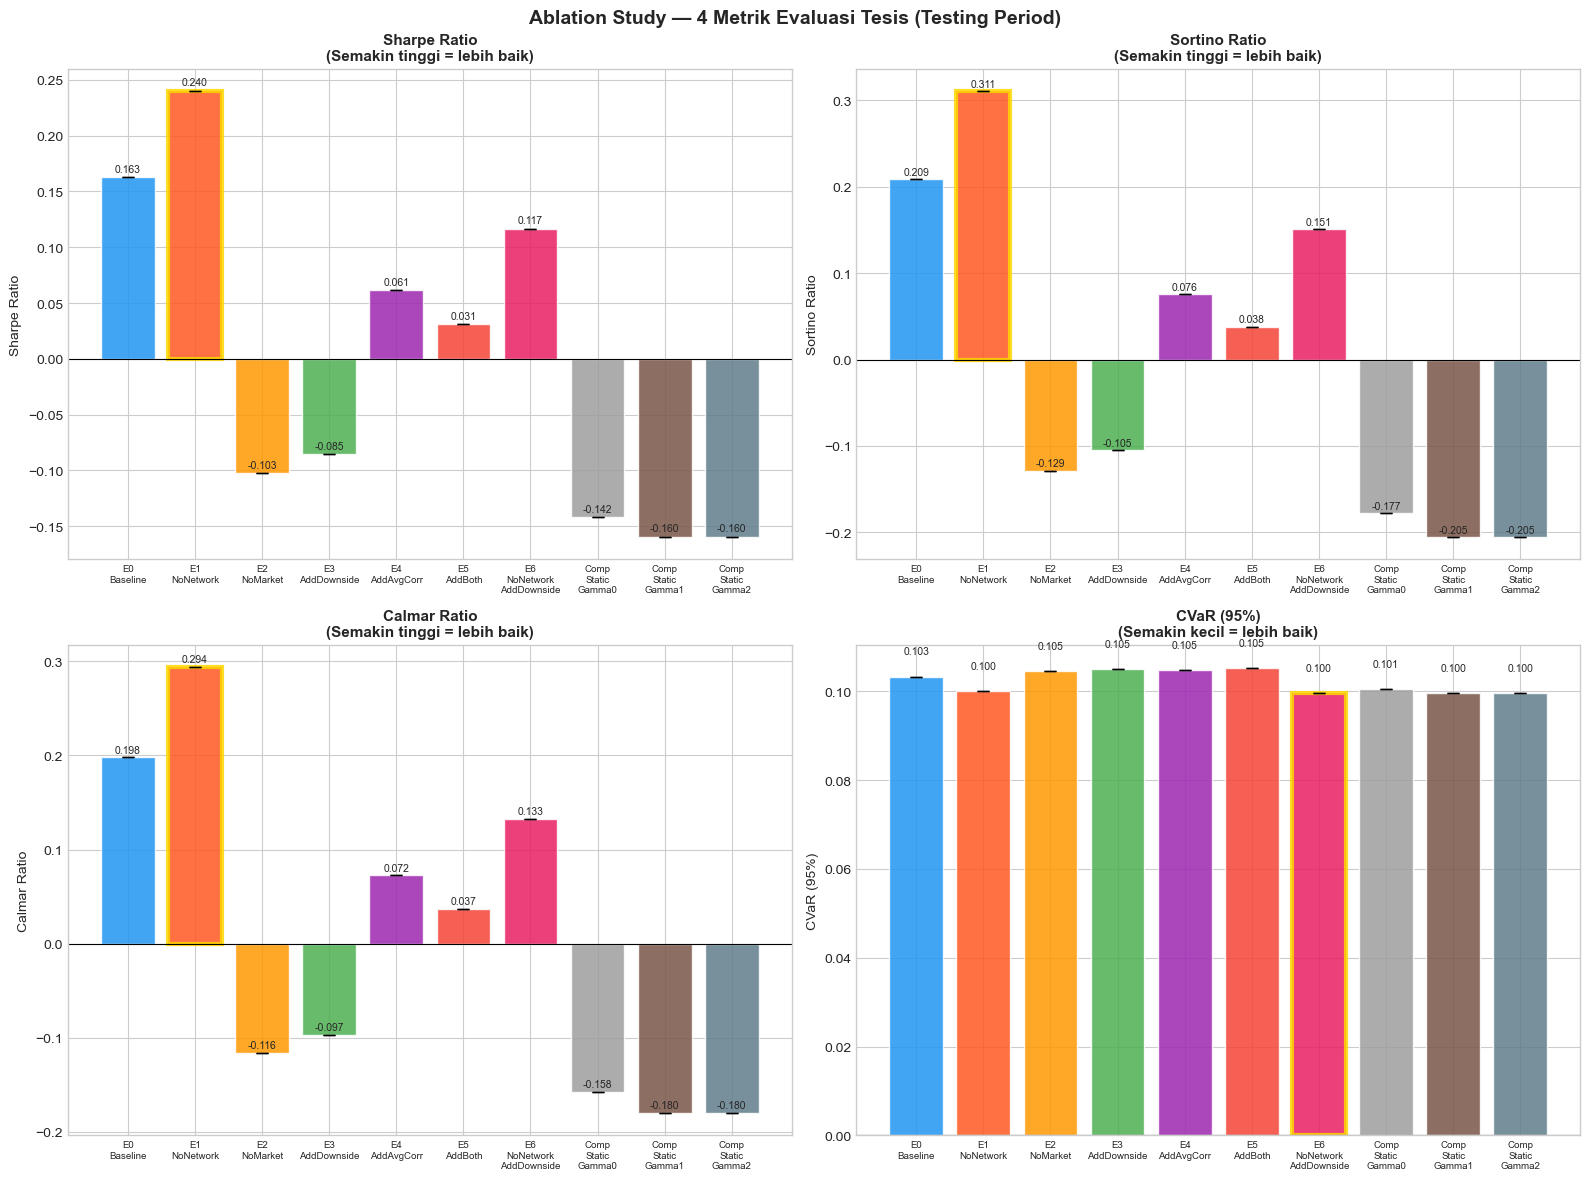

Saved: ablation_results_4metrics/4metrics_bar.png


In [36]:
# ================================================================
# VISUALISASI 1: Grouped Bar Chart — 4 Metrik (Testing)
# ================================================================

ABLATION_COLORS = {
    'E0_Baseline'        : '#2196F3',
    'E1_NoNetwork'       : '#FF5722',
    'E2_NoMarket'        : '#FF9800',
    'E3_AddDownside'     : '#4CAF50',
    'E4_AddAvgCorr'      : '#9C27B0',
    'E5_AddBoth'         : '#F44336',
    'E6_NoNetwork_AddDownside': '#E91E63',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
}

exp_ids = list(ABLATION_CONFIGS.keys())
colors  = [ABLATION_COLORS[e] for e in exp_ids]

metrics_to_plot = [
    ('SharpeRatio_Test_Mean',  'SharpeRatio_Test_Std',  'Sharpe Ratio',  'Semakin tinggi = lebih baik', False),
    ('SortinoRatio_Test_Mean', 'SortinoRatio_Test_Std', 'Sortino Ratio', 'Semakin tinggi = lebih baik', False),
    ('CalmarRatio_Test_Mean',  'CalmarRatio_Test_Std',  'Calmar Ratio',  'Semakin tinggi = lebih baik', False),
    ('CVaR95pct_Test_Mean',    'CVaR95pct_Test_Std',    'CVaR (95%)',    'Semakin kecil = lebih baik',  True),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ablation Study — 4 Metrik Evaluasi Tesis (Testing Period)',
             fontsize=14, fontweight='bold')

for ax, (mean_col, std_col, label, note, lower_better) in zip(axes.flatten(), metrics_to_plot):
    vals = summary_df.loc[exp_ids, mean_col].values
    errs = summary_df.loc[exp_ids, std_col].values

    bars = ax.bar(range(len(exp_ids)), vals, yerr=errs,
                  color=colors, edgecolor='white', capsize=4, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)

    # Highlight best
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    ax.set_xticks(range(len(exp_ids)))
    ax.set_xticklabels([e.replace('_', '\n') for e in exp_ids], fontsize=7)
    ax.set_ylabel(label)
    ax.set_title(f'{label}\n({note})', fontsize=11, fontweight='bold')

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (errs[list(vals).index(v)] if v >= 0 else 0) + 0.005,
                f'{v:.3f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_bar.png')

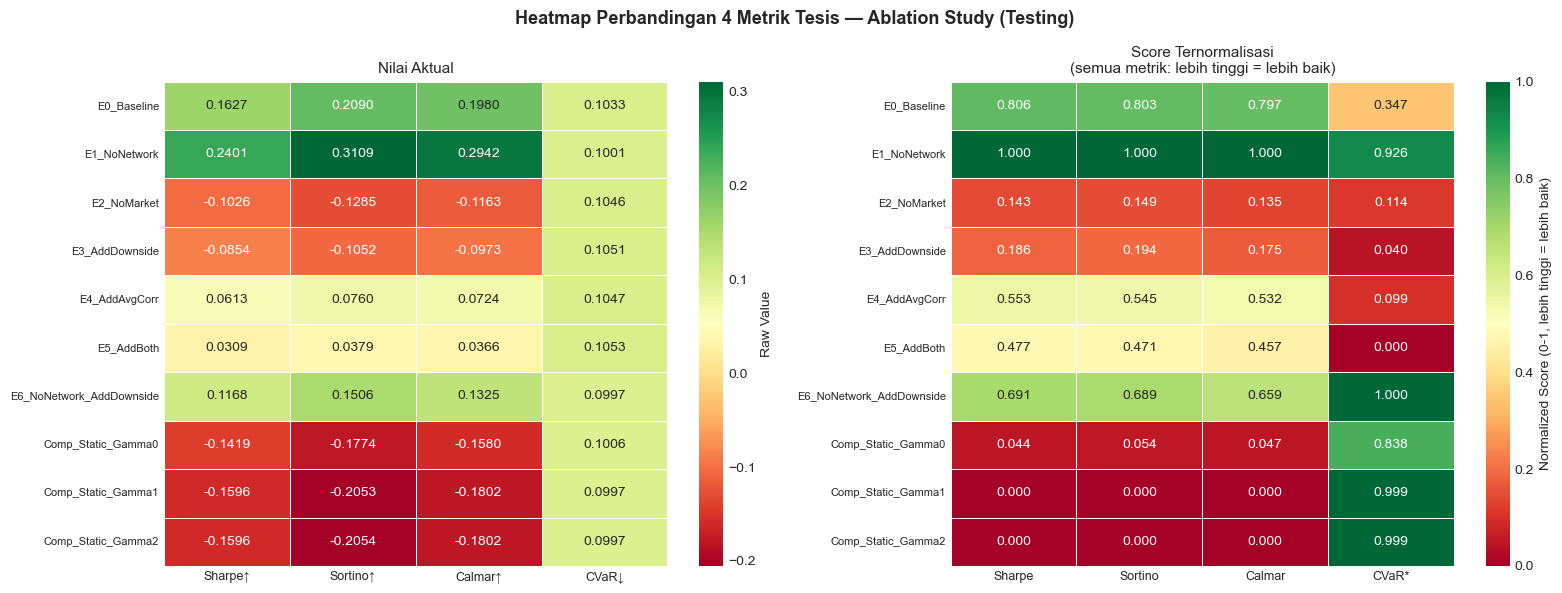

Saved: ablation_results_4metrics/4metrics_heatmap.png


In [37]:
# ================================================================
# VISUALISASI 2: Heatmap 4 Metrik per Eksperimen
# ================================================================

metric_cols = [
    ('SharpeRatio_Test_Mean',  'Sharpe'),
    ('SortinoRatio_Test_Mean', 'Sortino'),
    ('CalmarRatio_Test_Mean',  'Calmar'),
    ('CVaR95pct_Test_Mean',    'CVaR(95%)'),
]

heatmap_data = pd.DataFrame(
    {label: summary_df[col] for col, label in metric_cols},
    index=exp_ids
).astype(float)

# Normalisasi per kolom (0-1) agar skala sebanding
# CVaR: invert dulu (lebih kecil = lebih baik)
heatmap_norm = heatmap_data.copy()
for col in ['Sharpe', 'Sortino', 'Calmar']:
    mn, mx = heatmap_norm[col].min(), heatmap_norm[col].max()
    heatmap_norm[col] = (heatmap_norm[col] - mn) / (mx - mn + 1e-8)

# CVaR: invert normalisasi
mn, mx = heatmap_norm['CVaR(95%)'].min(), heatmap_norm['CVaR(95%)'].max()
heatmap_norm['CVaR(95%)'] = 1 - (heatmap_norm['CVaR(95%)'] - mn) / (mx - mn + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Heatmap Perbandingan 4 Metrik Tesis — Ablation Study (Testing)',
             fontsize=13, fontweight='bold')

# Raw values
sns.heatmap(heatmap_data, ax=axes[0], annot=True, fmt='.4f',
            cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Raw Value'})
axes[0].set_title('Nilai Aktual', fontsize=11)
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', labelsize=8, rotation=0)
axes[0].set_xticklabels(['Sharpe↑', 'Sortino↑', 'Calmar↑', 'CVaR↓'], fontsize=9)

# Normalized (higher = better for all)
sns.heatmap(heatmap_norm, ax=axes[1], annot=True, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Normalized Score (0-1, lebih tinggi = lebih baik)'})
axes[1].set_title('Score Ternormalisasi\n(semua metrik: lebih tinggi = lebih baik)', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=8, rotation=0)
axes[1].set_xticklabels(['Sharpe', 'Sortino', 'Calmar', 'CVaR*'], fontsize=9)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_heatmap.png')

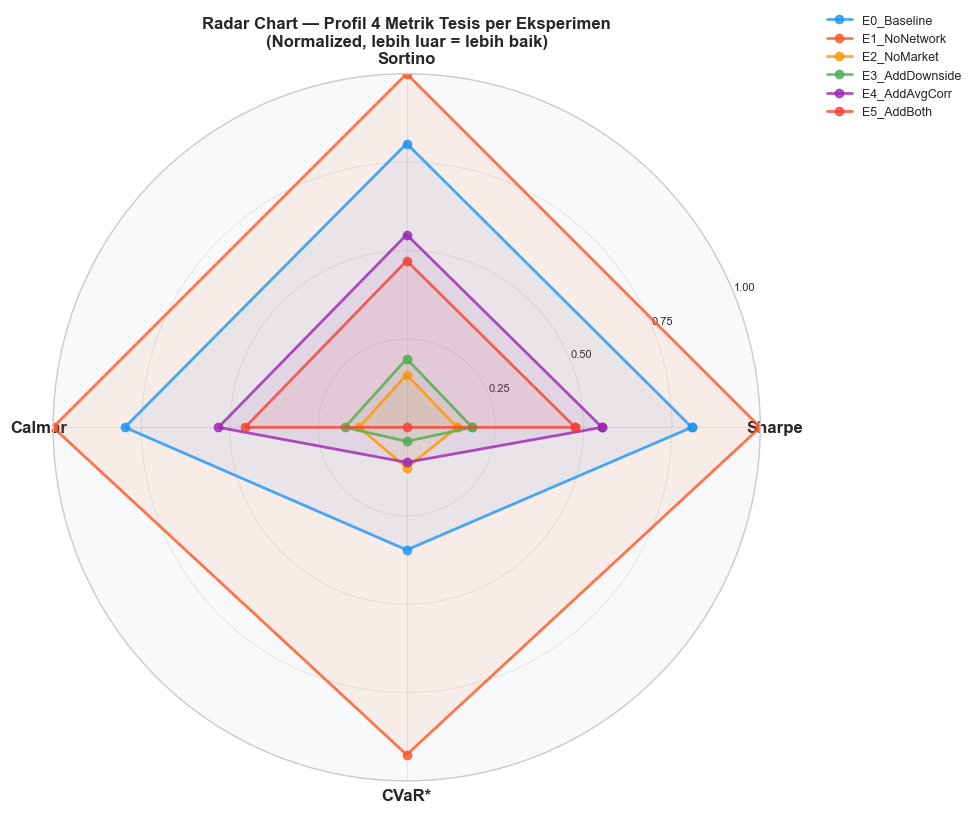

Saved: ablation_results_4metrics/4metrics_radar.png


In [38]:
# ================================================================
# VISUALISASI 3: Radar Chart — Profil Risiko per Eksperimen
# ================================================================

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_metrics = ['Sharpe', 'Sortino', 'Calmar', 'CVaR*']
N_metrics = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_metrics, endpoint=False).tolist()
angles += angles[:1]  # tutup loop

# Pilih eksperimen utama (bukan static benchmark) untuk radar
main_exps = ['E0_Baseline', 'E1_NoNetwork', 'E2_NoMarket',
             'E3_AddDownside', 'E4_AddAvgCorr', 'E5_AddBoth']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#F8F9FA')

for exp_id in main_exps:
    values = heatmap_norm.loc[exp_id, ['Sharpe', 'Sortino', 'Calmar', 'CVaR(95%)']].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=ABLATION_COLORS[exp_id], label=exp_id, alpha=0.8)
    ax.fill(angles, values, alpha=0.08, color=ABLATION_COLORS[exp_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Radar Chart — Profil 4 Metrik Tesis per Eksperimen\n(Normalized, lebih luar = lebih baik)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_radar.png')

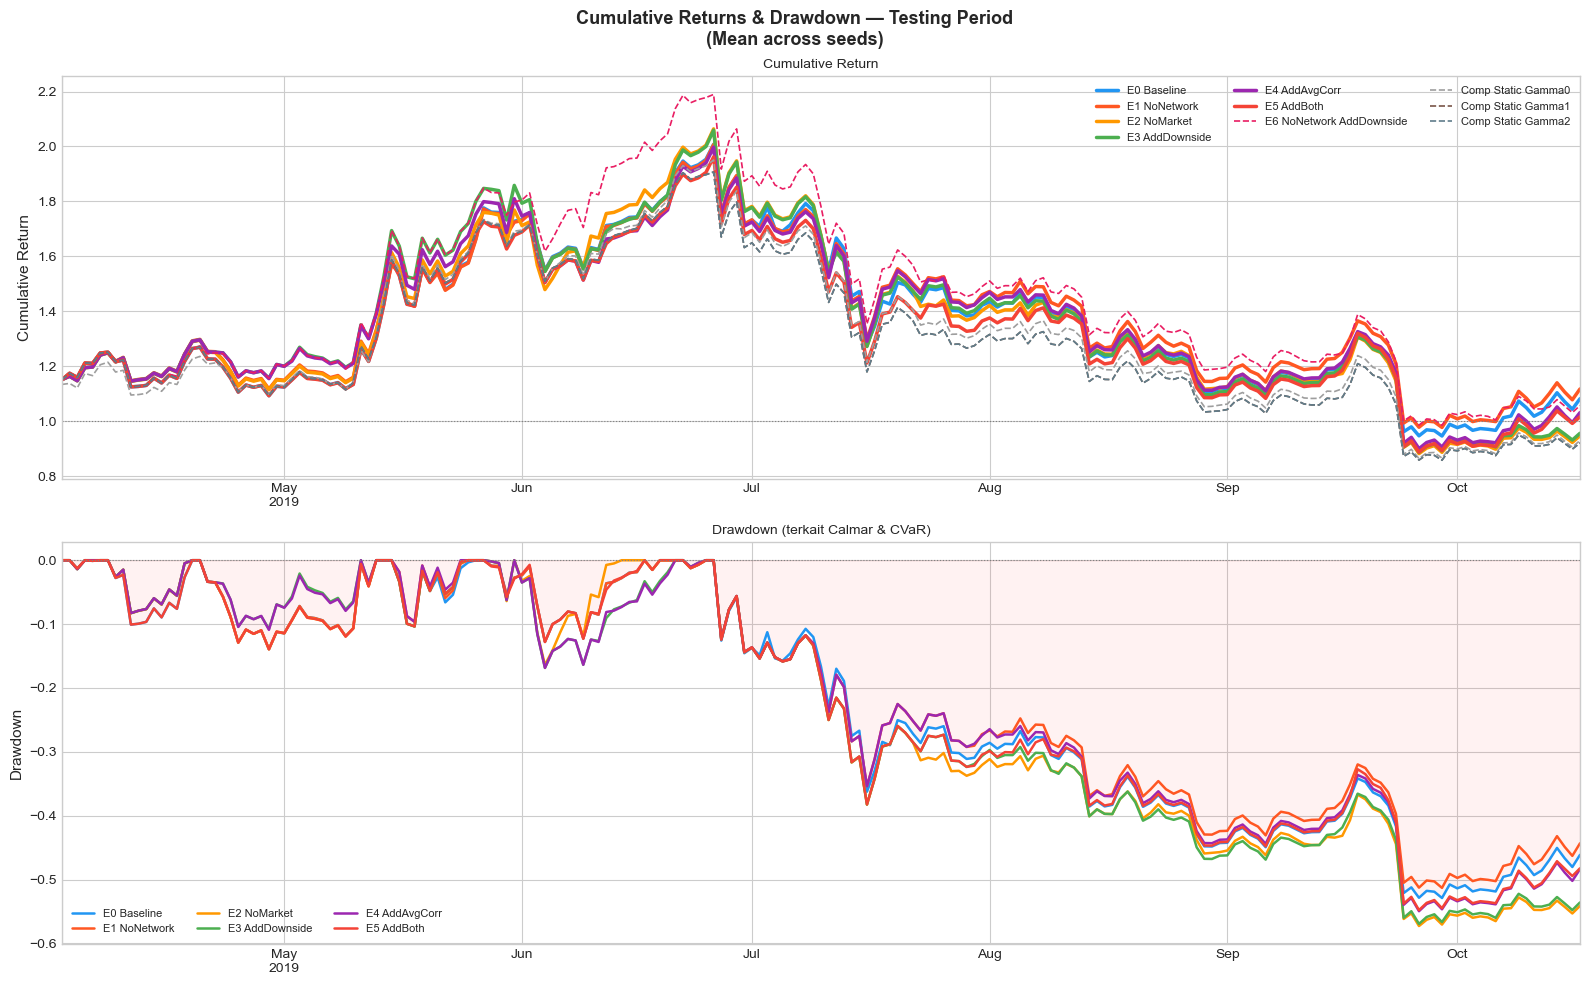

Saved: ablation_results_4metrics/cumret_drawdown.png


In [39]:
# ================================================================
# VISUALISASI 4: Cumulative Returns + Drawdown (Testing)
# ================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
fig.suptitle('Cumulative Returns & Drawdown — Testing Period\n(Mean across seeds)',
             fontsize=13, fontweight='bold')

# Panel 1: Cumulative Returns
ax1 = axes[0]
for exp_id in exp_ids:
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    cum = (1 + mean_ret).cumprod()
    lw = 2.5 if exp_id in main_exps else 1.2
    ls = '-' if exp_id in main_exps else '--'
    cum.plot(ax=ax1, label=exp_id.replace('_', ' '), color=ABLATION_COLORS[exp_id],
             linewidth=lw, linestyle=ls)

ax1.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax1.set_ylabel('Cumulative Return', fontsize=11)
ax1.set_title('Cumulative Return', fontsize=10)
ax1.legend(fontsize=8, ncol=3)

# Panel 2: Drawdown
ax2 = axes[1]
for exp_id in main_exps:  # hanya main experiments
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    cum = (1 + mean_ret).cumprod()
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    dd.plot(ax=ax2, label=exp_id.replace('_', ' '),
            color=ABLATION_COLORS[exp_id], linewidth=1.8)

ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax2.fill_between(ax2.get_lines()[0].get_xdata(),
                 ax2.get_lines()[0].get_ydata(), 0, alpha=0.05, color='red')
ax2.set_ylabel('Drawdown', fontsize=11)
ax2.set_title('Drawdown (terkait Calmar & CVaR)', fontsize=10)
ax2.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/cumret_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/cumret_drawdown.png')

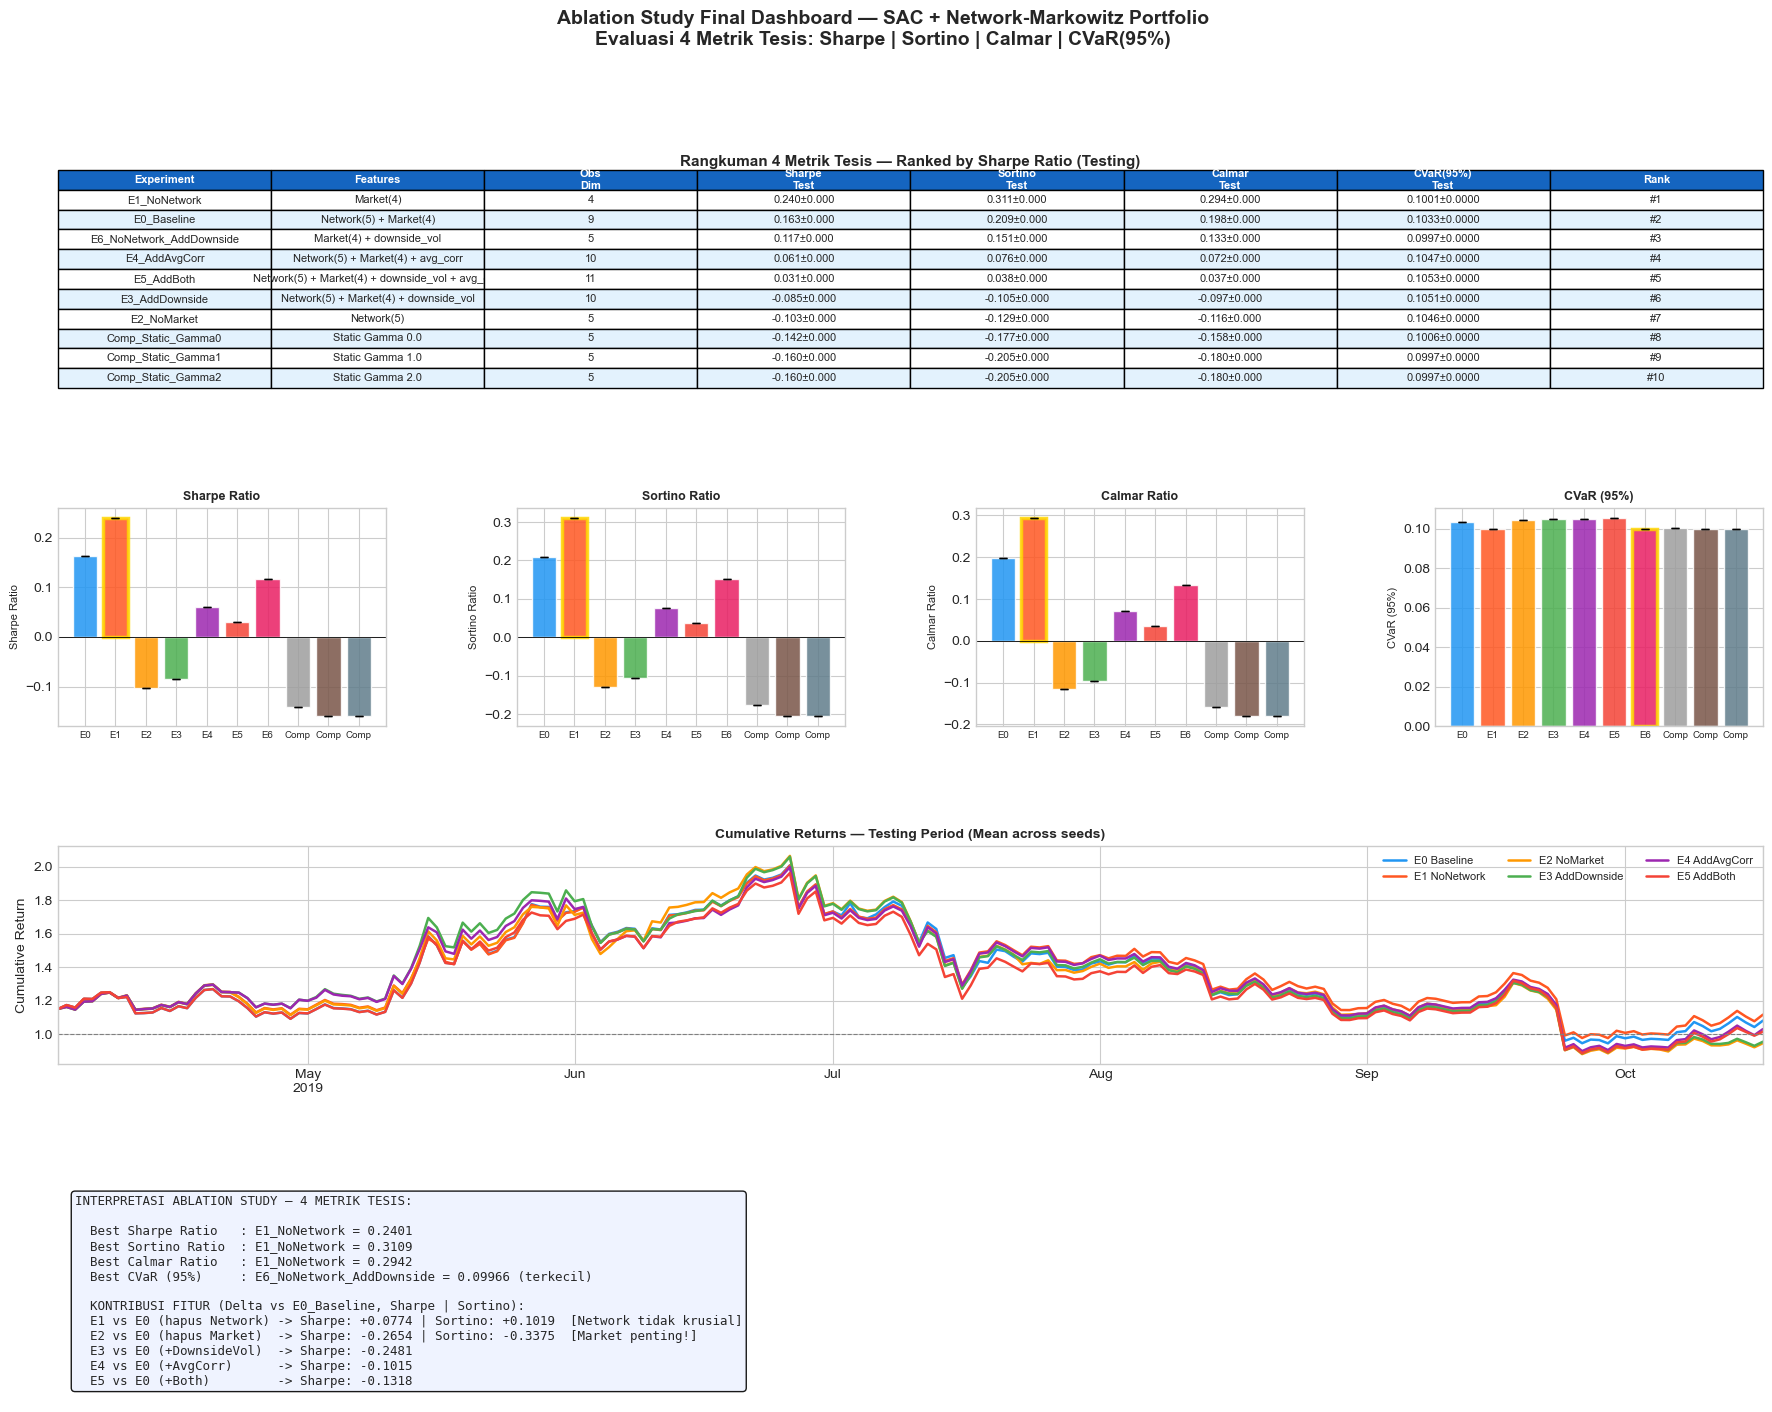


✅ Ablation Study dengan 4 Metrik Tesis Selesai!
Outputs saved to ablation_results_4metrics/:
  - ablation_summary_4metrics.csv
  - feature_correlation.png
  - 4metrics_bar.png
  - 4metrics_heatmap.png
  - 4metrics_radar.png
  - cumret_drawdown.png
  - final_dashboard_4metrics.png


In [40]:
# ================================================================
# VISUALISASI 5: Final Dashboard Tesis
# ================================================================

fig = plt.figure(figsize=(22, 16))
fig.suptitle(
    'Ablation Study Final Dashboard — SAC + Network-Markowitz Portfolio\n'
    'Evaluasi 4 Metrik Tesis: Sharpe | Sortino | Calmar | CVaR(95%)',
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.4)

# ── Panel 1: Summary Table (baris atas penuh) ──────────────────
ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis('off')

ranked_df = summary_df.sort_values('SharpeRatio_Test_Mean', ascending=False)
tbl_data, col_labels = [], [
    'Experiment', 'Features', 'Obs\nDim',
    'Sharpe\nTest', 'Sortino\nTest', 'Calmar\nTest', 'CVaR(95%)\nTest', 'Rank'
]
for rank, (exp_id, row) in enumerate(ranked_df.iterrows(), 1):
    tbl_data.append([
        exp_id,
        row['Features'],
        int(row['Obs Dim']),
        f"{row['SharpeRatio_Test_Mean']:.3f}±{row['SharpeRatio_Test_Std']:.3f}",
        f"{row['SortinoRatio_Test_Mean']:.3f}±{row['SortinoRatio_Test_Std']:.3f}",
        f"{row['CalmarRatio_Test_Mean']:.3f}±{row['CalmarRatio_Test_Std']:.3f}",
        f"{row['CVaR95pct_Test_Mean']:.4f}±{row['CVaR95pct_Test_Std']:.4f}",
        f'#{rank}'
    ])

tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, (exp_id, _) in enumerate(ranked_df.iterrows(), 1):
    fc = '#E3F2FD' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(fc)
ax_tbl.set_title('Rangkuman 4 Metrik Tesis — Ranked by Sharpe Ratio (Testing)',
                 fontsize=11, fontweight='bold', pad=3)

# ── Panel 2-5: Bar chart per metrik ────────────────────────────
metric_panels = [
    ('SharpeRatio_Test_Mean',  'SharpeRatio_Test_Std',  'Sharpe Ratio',  False, gs[1, 0]),
    ('SortinoRatio_Test_Mean', 'SortinoRatio_Test_Std', 'Sortino Ratio', False, gs[1, 1]),
    ('CalmarRatio_Test_Mean',  'CalmarRatio_Test_Std',  'Calmar Ratio',  False, gs[1, 2]),
    ('CVaR95pct_Test_Mean',    'CVaR95pct_Test_Std',    'CVaR (95%)',    True,  gs[1, 3]),
]

for mean_col, std_col, label, lower_better, gs_pos in metric_panels:
    ax = fig.add_subplot(gs_pos)
    vals = summary_df.loc[exp_ids, mean_col].values
    errs = summary_df.loc[exp_ids, std_col].values
    bars = ax.bar(range(len(exp_ids)), vals, yerr=errs,
                  color=colors, edgecolor='white', capsize=3, alpha=0.85)
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(range(len(exp_ids)))
    ax.set_xticklabels([e.split('_')[0] for e in exp_ids], fontsize=7)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel(label, fontsize=8)

# ── Panel 6: Cumulative Returns ────────────────────────────────
ax_cum = fig.add_subplot(gs[2, :])
for exp_id in main_exps:
    mean_ret = pd.concat(
        [ablation_results[exp_id]['test'][s] for s in SEEDS], axis=1
    ).mean(axis=1)
    (1 + mean_ret).cumprod().plot(
        ax=ax_cum, label=exp_id.replace('_', ' '),
        color=ABLATION_COLORS[exp_id], linewidth=1.8
    )
ax_cum.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax_cum.set_title('Cumulative Returns — Testing Period (Mean across seeds)', fontsize=10, fontweight='bold')
ax_cum.set_ylabel('Cumulative Return')
ax_cum.legend(fontsize=8, ncol=3)

# ── Panel 7: Interpretasi otomatis ────────────────────────────
ax_interp = fig.add_subplot(gs[3, :])
ax_interp.axis('off')

best_sharpe  = summary_df['SharpeRatio_Test_Mean'].idxmax()
best_sortino = summary_df['SortinoRatio_Test_Mean'].idxmax()
best_calmar  = summary_df['CalmarRatio_Test_Mean'].idxmax()
best_cvar    = summary_df['CVaR95pct_Test_Mean'].idxmin()

base_sharpe  = summary_df.loc['E0_Baseline', 'SharpeRatio_Test_Mean']
base_sortino = summary_df.loc['E0_Baseline', 'SortinoRatio_Test_Mean']
base_calmar  = summary_df.loc['E0_Baseline', 'CalmarRatio_Test_Mean']
base_cvar    = summary_df.loc['E0_Baseline', 'CVaR95pct_Test_Mean']

e1_s  = summary_df.loc['E1_NoNetwork', 'SharpeRatio_Test_Mean']  - base_sharpe
e2_s  = summary_df.loc['E2_NoMarket',  'SharpeRatio_Test_Mean']  - base_sharpe
e1_so = summary_df.loc['E1_NoNetwork', 'SortinoRatio_Test_Mean'] - base_sortino
e2_so = summary_df.loc['E2_NoMarket',  'SortinoRatio_Test_Mean'] - base_sortino

interpretasi = (
    "INTERPRETASI ABLATION STUDY — 4 METRIK TESIS:\n\n"
    f"  Best Sharpe Ratio   : {best_sharpe} = {summary_df.loc[best_sharpe,  'SharpeRatio_Test_Mean']:.4f}\n"
    f"  Best Sortino Ratio  : {best_sortino} = {summary_df.loc[best_sortino, 'SortinoRatio_Test_Mean']:.4f}\n"
    f"  Best Calmar Ratio   : {best_calmar} = {summary_df.loc[best_calmar,  'CalmarRatio_Test_Mean']:.4f}\n"
    f"  Best CVaR (95%)     : {best_cvar} = {summary_df.loc[best_cvar,     'CVaR95pct_Test_Mean']:.5f} (terkecil)\n\n"
    "  KONTRIBUSI FITUR (Delta vs E0_Baseline, Sharpe | Sortino):\n"
    f"  E1 vs E0 (hapus Network) -> Sharpe: {e1_s:+.4f} | Sortino: {e1_so:+.4f}  "
    f"{'[Network penting!]' if e1_s < 0 else '[Network tidak krusial]'}\n"
    f"  E2 vs E0 (hapus Market)  -> Sharpe: {e2_s:+.4f} | Sortino: {e2_so:+.4f}  "
    f"{'[Market penting!]' if e2_s < 0 else '[Market tidak krusial]'}\n"
    f"  E3 vs E0 (+DownsideVol)  -> Sharpe: {summary_df.loc['E3_AddDownside','SharpeRatio_Test_Mean']-base_sharpe:+.4f}\n"
    f"  E4 vs E0 (+AvgCorr)      -> Sharpe: {summary_df.loc['E4_AddAvgCorr','SharpeRatio_Test_Mean']-base_sharpe:+.4f}\n"
    f"  E5 vs E0 (+Both)         -> Sharpe: {summary_df.loc['E5_AddBoth','SharpeRatio_Test_Mean']-base_sharpe:+.4f}"
)

ax_interp.text(0.01, 0.95, interpretasi, transform=ax_interp.transAxes,
               fontsize=9, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#EEF2FF', alpha=0.9))

plt.savefig('ablation_results_4metrics/final_dashboard_4metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Ablation Study dengan 4 Metrik Tesis Selesai!')
print('Outputs saved to ablation_results_4metrics/:')
print('  - ablation_summary_4metrics.csv')
print('  - feature_correlation.png')
print('  - 4metrics_bar.png')
print('  - 4metrics_heatmap.png')
print('  - 4metrics_radar.png')
print('  - cumret_drawdown.png')
print('  - final_dashboard_4metrics.png')